# Depolarizing Channel $\Lambda_p$ & Proposition 1
## No Dataset | Random Density Matrices | Circuit NISQ Demo (Synthetic Features)
### To Confirm: $D_{\mathrm{tr}}(\Lambda_p(\rho),\Lambda_p(\sigma)) = (1-p)\,D_{\mathrm{tr}}(\rho,\sigma)$

## Setup


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pennylane as qp
import torch
from pennylane import numpy as np

In [2]:
from scripts.circuit import (
    build_forward_circuit,
    create_quantum_device,
    initialize_random_weights,
)
from scripts.constants import (
    DEFAULT_N_PAIRS,
    DEFAULT_NOISE_RATE,
    DEFAULT_P_VALS,
    DEFAULT_SEED,
    PROP1_RESIDUAL_TOL,
)
from scripts.logging import write_history_log
from scripts.quantum_metrics import trace_distance
from scripts.theory import (
    _random_density_matrix,
    assert_proposition1,
    check_proposition1_synthetic,
    depolarizing_channel_global,
    regulariser_contraction_curve,
)
from scripts.utils import get_torch_device

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


In [4]:
NOTEBOOK_NAME = "15.depolarizing-channel"
SEED = DEFAULT_SEED
torch.manual_seed(SEED)
np.random.seed(SEED)

device = get_torch_device()
print(f"torch device: {device}")

torch device: cuda


## Proposition 1: Noise Contraction

### Claim:

For the global $n$-qubit depolarizing channel
$$
\Lambda_p(\rho) = (1-p)\rho + p\,\frac{I}{2^n}
$$
and any density matrices $\rho,\sigma$,
$$
D_{\mathrm{tr}}\big(\Lambda_p(\rho),\,\Lambda_p(\sigma)\big)
= (1-p)\,D_{\mathrm{tr}}(\rho,\sigma)
$$
is true.

In other words, depolarizing noise **rescales** Hilbert-space geometry by $(1-p)$; it **does not distort** relative angles between pairs.

### Note:

- This is an **exact** identity.
- Residuals should be machine precision ($\sim 10^{-10}$ or smaller).

### To Test:

- $p=0$ (identity), $p=1$ (collapse to maximally mixed state $I/d$, distance $0$), and intermediate $p$.
- **No dataset is required** for this check as random states are the correct testbed.

## $\Lambda_p$ Implementation

See `scripts/theory.py`.

## Numerical Confirmation of Proposition 1

For each $n\in\{1,2,3\}$ qubits and $p\in\{0.0, 0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 1.0\}$ or `DEFAULT_P_VALS`, test *Proposition 1* on 64 or `DEFAULT_N_PAIRS` random pairs $(ρ,σ)$.

In [5]:
n_pairs = DEFAULT_N_PAIRS
p_grid = list(DEFAULT_P_VALS)
qubit_grid = [1, 2, 3]
tol = PROP1_RESIDUAL_TOL

In [6]:
rows = []
t0 = time.perf_counter()
for n_qubits in qubit_grid:
    dim = 2**n_qubits
    for r in check_proposition1_synthetic(
        dim, p_values=p_grid, n_pairs=n_pairs, seed=SEED
    ):
        rows.append(
            {
                "n_qubits": n_qubits,
                "p": r["p"],
                "D_tr_clean": r["D_tr_clean"],
                "D_tr_noisy": r["D_tr_noisy"],
                "D_tr_expected": r["D_tr_expected"],
                "residual": float(r["residual"]),
            }
        )

rec_df = pd.DataFrame(rows)
elapsed = time.perf_counter() - t0
print(f"prop-1 sweep done in {elapsed:.2f}s")
rec_df

prop-1 sweep done in 1.51s


,n_qubits,p,D_tr_clean,D_tr_noisy,D_tr_expected,residual
0,1,0.00,0.934685,0.934685,0.934685,0.000000e+00
1,1,0.01,0.934685,0.925338,0.925338,0.000000e+00
2,1,0.05,0.934685,0.887951,0.887951,0.000000e+00
3,1,0.10,0.934685,0.841216,0.841216,0.000000e+00
4,1,0.30,0.934685,0.654279,0.654279,0.000000e+00
...,...,...,...,...,...,...
1531,3,0.10,0.935696,0.842127,0.842127,2.220446e-16
1532,3,0.30,0.935696,0.654987,0.654987,2.220446e-16
1533,3,0.50,0.935696,0.467848,0.467848,1.110223e-16
1534,3,0.70,0.935696,0.280709,0.280709,1.110223e-16


In [7]:
# optional summary table (derived, no re-run)
prop1_df = rec_df.groupby(["n_qubits", "p"], as_index=False).agg(
    n_pairs=("residual", "size"),
    resid_max=("residual", "max"),
    resid_mean=("residual", "mean"),
    resid_median=("residual", "median"),
)
prop1_df

,n_qubits,p,n_pairs,resid_max,resid_mean,resid_median
0,1,0.00,64,0.000000e+00,0.000000e+00,0.000000e+00
1,1,0.01,64,2.220446e-16,6.505213e-17,5.551115e-17
2,1,0.05,64,2.220446e-16,5.659535e-17,5.551115e-17
3,1,0.10,64,1.665335e-16,5.204170e-17,5.551115e-17
4,1,0.30,64,1.110223e-16,4.358493e-17,5.551115e-17
5,1,0.50,64,1.110223e-16,1.593777e-17,0.000000e+00
6,1,0.70,64,8.326673e-17,1.929880e-17,2.081668e-17
7,1,1.00,64,0.000000e+00,0.000000e+00,0.000000e+00
8,2,0.00,64,0.000000e+00,0.000000e+00,0.000000e+00
9,2,0.01,64,7.771561e-16,1.500536e-16,1.110223e-16


In [8]:
# assert Proposition-1 residuals are near machine eps across the whole sweep
worst = float(prop1_df["resid_max"].max())
assert worst <= tol, f"Proposition-1 residual too large: {worst}"
print(f"Proposition 1 PASSED | worst residual = {worst:.3e} <= {tol:g}")

Proposition 1 PASSED | worst residual = 8.882e-16 <= 1e-10


In [9]:
# assert for only edge cases: p=0 (identity) and p=1 (collapse to I/d)
# dimension = 4 with 2 qubits
records_edge = check_proposition1_synthetic(
    4, p_values=(0.0, 1.0), n_pairs=8, seed=SEED
)
worst_edge = assert_proposition1(records_edge, tol=tol)
print(f"p=0/1 edge check PASSED | worst residual = {worst_edge:.3e}")

p=0/1 edge check PASSED | worst residual = 0.000e+00


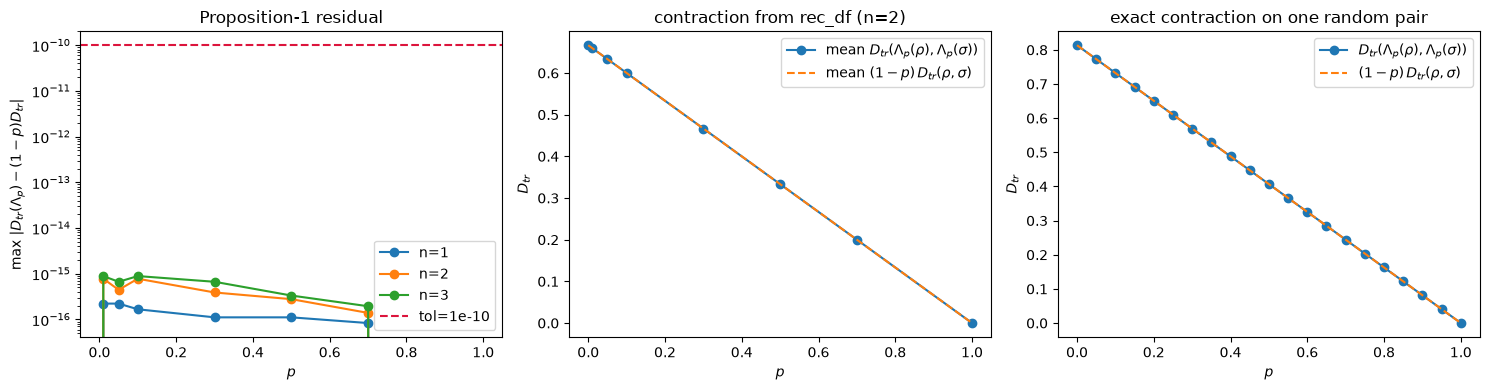

In [10]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# left: max residual vs p
for n_qubits, g in rec_df.groupby("n_qubits"):
    s = g.groupby("p")["residual"].max()
    axes[0].plot(s.index, s.values, marker="o", label=f"n={n_qubits}")
axes[0].axhline(tol, color="crimson", linestyle="--", label=f"tol={tol:g}")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$p$")
axes[0].set_ylabel(r"max $|D_{tr}(\Lambda_p)-(1-p)D_{tr}|$")
axes[0].set_title("Proposition-1 residual")
axes[0].legend()

# middle: mean contraction from same records
g2 = rec_df[rec_df["n_qubits"] == 2]
s_noisy = g2.groupby("p")["D_tr_noisy"].mean()
s_exp = g2.groupby("p")["D_tr_expected"].mean()
axes[1].plot(
    s_noisy.index,
    s_noisy.values,
    "o-",
    label=r"mean $D_{tr}(\Lambda_p(\rho),\Lambda_p(\sigma))$",
)
axes[1].plot(
    s_exp.index, s_exp.values, "--", label=r"mean $(1-p)\,D_{tr}(\rho,\sigma)$"
)
axes[1].set_xlabel(r"$p$")
axes[1].set_ylabel(r"$D_{tr}$")
axes[1].set_title("contraction from rec_df (n=2)")
axes[1].legend()

# right: contraction on one fixed pair
rho = _random_density_matrix(dim, device)
sigma = _random_density_matrix(dim, device)
p_fine = np.linspace(0.0, 1.0, 21)
d_clean = float(trace_distance(rho, sigma))
d_noisy = [
    float(
        trace_distance(
            depolarizing_channel_global(rho, float(p)),
            depolarizing_channel_global(sigma, float(p)),
        )
    )
    for p in p_fine
]
axes[2].plot(
    p_fine, d_noisy, "o-", label=r"$D_{tr}(\Lambda_p(\rho),\Lambda_p(\sigma))$"
)
axes[2].plot(
    p_fine, (1.0 - p_fine) * d_clean, "--", label=r"$(1-p)\,D_{tr}(\rho,\sigma)$"
)
axes[2].set_xlabel(r"$p$")
axes[2].set_ylabel(r"$D_{tr}$")
axes[2].set_title("exact contraction on one random pair")
axes[2].legend()

plt.tight_layout()
plt.show()

## $p$ as NISQ Noise (Circuit)

In the QS-Net forward path, $p$ enters as per-wire `DepolarizingChannel` after each variational layer:

$$
x \xrightarrow{\phi} \ket{\psi(x)}
\xrightarrow{U(\theta)} \ket{\Phi(x)}
\xrightarrow{\Lambda_p^{\otimes}} \rho(x)
$$

In [11]:
num_qubits = 4
num_layers = 2
noise_rate = DEFAULT_NOISE_RATE  # default NISQ knob

dev = create_quantum_device(num_qubits)
forward_circuit = build_forward_circuit(
    dev, num_qubits, num_layers, noise_rate=noise_rate
)
theta = initialize_random_weights(num_layers, num_qubits, device)

# synthetic features in [0, pi]
X_syn = torch.rand(8, num_qubits, device=device) * np.pi
with torch.no_grad():
    z, rho_batch = forward_circuit(X_syn, theta)

print(f"noise rate (p) = {noise_rate}")
print(f"weights (theta) shape = {tuple(theta.shape)}")
print(f"density-matrix (rho) batch shape = {tuple(rho_batch.shape)}")
print(
    f"mean |Pauli-Z measurement| = {torch.stack([zi.abs().mean() for zi in z]).mean().item():.4f}"
)

noise rate (p) = 0.01
weights (theta) shape = (2, 4, 3)
density-matrix (rho) batch shape = (8, 16, 16)
mean |Pauli-Z measurement| = 0.3053


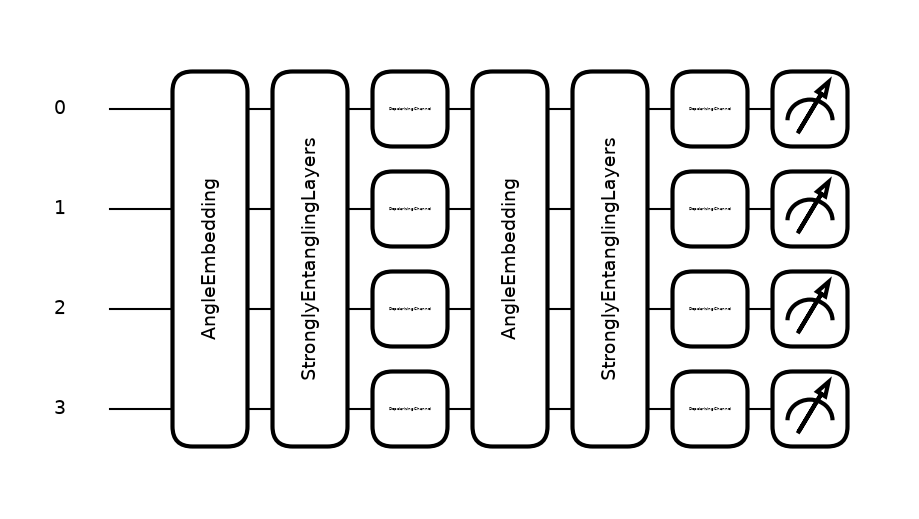

In [12]:
# draw one sample through the noisy circuit
fig, ax = qp.draw_mpl(forward_circuit)(X_syn[:1], theta)
plt.show()

## $p$ as a Regulariser Knob

Because Proposition 1 contracts *every* pair by $(1-p)$, raising $p$:

- shrinks inter-prototype / inter-sample trace distances
- softens Hilbert-space geometry (harder to over-separate classes)
- shrinks the certified radius denominator factor $(1-p)$ in Algo 3

So the same scalar is both a **hardware-noise model** and a **geometry regulariser**.

In [13]:
# run a noiseless circuit
dev_clean = create_quantum_device(num_qubits)
forward_clean = build_forward_circuit(
    dev_clean, num_qubits, num_layers, noise_rate=0.0
)  # noiseless

with torch.no_grad():
    _, rho_clean = forward_clean(X_syn, theta)

rho_list = [rho_clean[i] for i in range(rho_clean.shape[0])]

In [14]:
# raise p and check that average state-to-state distance shrinks by the factor (1-p)
p_reg_grid, d0, d_p, d_theory = regulariser_contraction_curve(rho_list)
reg_df = pd.DataFrame(
    {
        "p": p_reg_grid,
        "mean_pairwise_Dtr": d_p,
        "theory_(1-p)*D0": d_theory,
    }
)
reg_df

,p,mean_pairwise_Dtr,theory_(1-p)*D0
0,0.0,0.934506,0.934506
1,0.1,0.841055,0.841055
2,0.2,0.747605,0.747605
3,0.3,0.654154,0.654154
4,0.4,0.560704,0.560704
5,0.5,0.467253,0.467253
6,0.6,0.373802,0.373802
7,0.7,0.280352,0.280352
8,0.8,0.186901,0.186901
9,0.9,0.093451,0.093451


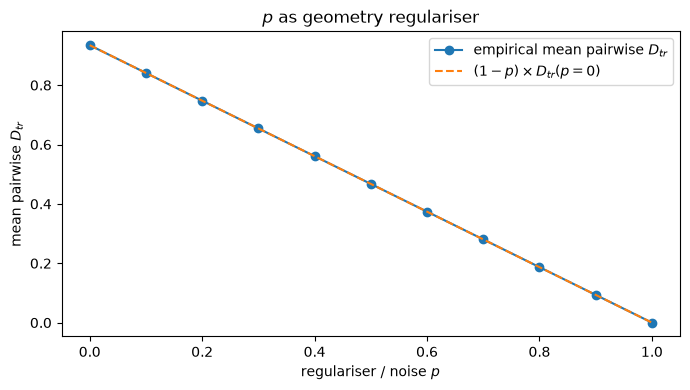

regulariser-curve residual max = 2.220e-16


In [15]:
# plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    reg_df["p"],
    reg_df["mean_pairwise_Dtr"],
    "o-",
    label="empirical mean pairwise $D_{tr}$",
)
ax.plot(
    reg_df["p"], reg_df["theory_(1-p)*D0"], "--", label=r"$(1-p)\times D_{tr}(p=0)$"
)
ax.set_xlabel(r"regulariser / noise $p$")
ax.set_ylabel(r"mean pairwise $D_{tr}$")
ax.set_title(r"$p$ as geometry regulariser")
ax.legend()
plt.tight_layout()
plt.show()

reg_resid = np.max(np.abs(reg_df["mean_pairwise_Dtr"] - reg_df["theory_(1-p)*D0"]))
print(f"regulariser-curve residual max = {reg_resid:.3e}")

## Logging


In [16]:
history = {
    "prop1_resid_max": prop1_df["resid_max"].tolist(),
    "prop1_resid_mean": prop1_df["resid_mean"].tolist(),
    "p_grid": p_grid,
    "reg_mean_pairwise_Dtr": reg_df["mean_pairwise_Dtr"].tolist(),
}

log_path = write_history_log(
    history,
    NOTEBOOK_NAME,
    extra={
        "seed": SEED,
        "n_pairs": n_pairs,
        "qubit_grid": qubit_grid,
        "p_grid": p_grid,
        "prop1_tol": tol,
        "prop1_worst_residual": worst,
        "prop1_passed": bool(worst <= tol),
        "circuit_num_qubits": num_qubits,
        "circuit_num_layers": num_layers,
        "circuit_noise_rate": noise_rate,
        "reg_p_grid": p_reg_grid.tolist(),
        "reg_D0": d0,
        "reg_resid_max": float(reg_resid),
        "dataset": None,
    },
)
print(f"wrote {log_path}")

# also dump the residual table
csv_path = Path("logs") / f"{NOTEBOOK_NAME}-prop1.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
prop1_df.to_csv(csv_path, index=False)
print(f"wrote {csv_path}")

wrote logs/15.depolarizing-channel.log
wrote logs/15.depolarizing-channel-prop1.csv
